## 1. Create data

In [141]:
from sklearn.datasets import make_circles
from helper_functions import plot_decision_boundary
# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.05,
                    random_state=42)

In [142]:
len(X), len(y)

(1000, 1000)

In [143]:
X.shape, y.shape

((1000, 2), (1000,))

In [144]:
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],
                    "X2":X[:,1],
                    "label":y})

circles.head(10)

,X1,X2,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0
5,-0.469885,0.708037,1
6,-0.016045,0.805623,1
7,0.759623,0.159526,1
8,-0.175692,-0.799837,1
9,-0.110616,1.042207,0


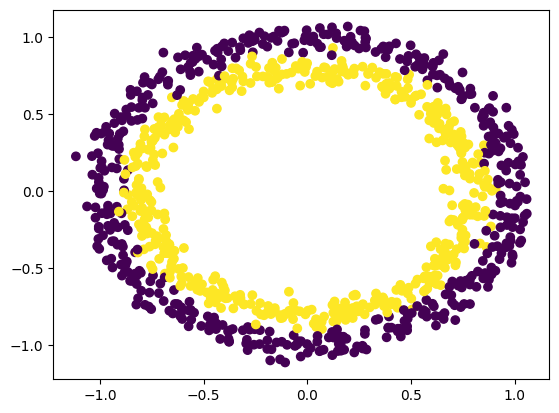

In [145]:
import matplotlib.pyplot as plt
plt.scatter(circles['X1'],
            circles['X2'],
            c=circles['label'])
plt.show()    

### 1.1 Turn data into tesnors

In [146]:
import torch 
torch.__version__

'2.11.0+cpu'

In [147]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
# X = torch.hstack([X,X**2]) acc in epoch 90 = 75%
X[:5], y[:5]

(tensor([[ 0.7422,  0.2467],
         [-0.7340,  0.1687],
         [-0.8299,  0.2220],
         [-0.4291,  0.6722],
         [ 0.4456, -0.8949]]),
 tensor([1., 1., 1., 1., 0.]))

In [148]:
# Split data into training/test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
                                                    

In [149]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [150]:
type(X_train), type(y_train), type(X_test), type(y_test)

(torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor)

## 2. Building a model

In [151]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [152]:
X_train.shape

torch.Size([800, 2])

In [153]:
class CircleModelV0(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=10)      
        self.layer_2 = nn.Linear(in_features=10, out_features=1)

        # self.two_linear_layer = nn.Sequential(
        #     nn.Linear(in_features=2, out_features=10),
        #     nn.Linear(in_features=10, out_features=1)
        #     )

    def forward(self, x:torch.Tensor):
        z1 = self.layer_1(x)
        z2 = self.relu_2(z1)

        return z2
        # return self.two_linear_layer(x)

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)

In [154]:
# Create model above with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Linear(in_features=10, out_features=1)
)
model_0.to(device)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=1, bias=True)
)

In [155]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.1918,  0.2976],
                      [ 0.6313,  0.4087],
                      [-0.3091,  0.4082],
                      [ 0.1265,  0.3591],
                      [-0.4310, -0.7000],
                      [-0.2732, -0.5424],
                      [ 0.5802,  0.2037],
                      [ 0.2929,  0.2236],
                      [-0.0123,  0.5534],
                      [-0.5024,  0.0445]])),
             ('0.bias',
              tensor([-0.4826,  0.2180, -0.2435,  0.2167, -0.1473,  0.5865, -0.4191, -0.4217,
                      -0.4217,  0.6360])),
             ('1.weight',
              tensor([[ 0.1054,  0.3043, -0.2610, -0.3137, -0.2474, -0.2127,  0.1281,  0.1132,
                        0.2628, -0.1633]])),
             ('1.bias', tensor([-0.2156]))])

In [156]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
untrained_preds.shape, y_test.shape

(torch.Size([200, 1]), torch.Size([200]))

In [157]:
untrained_preds[:10]

tensor([[-0.5340],
        [-0.1882],
        [-1.1216],
        [-0.3447],
        [-0.7192],
        [-0.5001],
        [ 0.1093],
        [ 0.0445],
        [-1.1671],
        [-0.1848]])

### 2.1 Setup loss & optimizer

In [158]:
# Setup the loss function 

# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_0.parameters(), 
                                lr=0.1)

In [159]:
# Calculate accuracy 
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 3. Train phase

### 3.1 Prediction labels

In [160]:
## Eval model 
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.5340],
        [-0.1882],
        [-1.1216],
        [-0.3447],
        [-0.7192]])

In [161]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [162]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3696],
        [0.4531],
        [0.2457],
        [0.4147],
        [0.3276]])

* `y_pred_probs` >= 0.5 `y=1` (class 1)

* `y_pred_probs` < 0.5 `y=0` (class 0)


In [163]:
y_preds = torch.round(y_pred_probs)

# In one line
y_predv2 = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(),y_predv2.squeeze()))

tensor([True, True, True, True, True])


### 3.2 Train model

In [164]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities
    #                 y_train)

    loss = loss_fn(y_logits, # nn.BCEWithLogistLoss expects raw logits as input
                    y_train)
    acc = accuracy_fn(y_true=y_train,
                        y_pred=y_pred)
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits,
                            y_test)
    test_acc = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.75898, Acc:42.62% | Test loss: 0.76429 | Test acc: 40.50%
Epoch: 10 | Loss: 0.71116, Acc:47.00% | Test loss: 0.72004 | Test acc: 47.50%
Epoch: 20 | Loss: 0.69973, Acc:48.88% | Test loss: 0.70746 | Test acc: 49.00%
Epoch: 30 | Loss: 0.69642, Acc:49.75% | Test loss: 0.70267 | Test acc: 49.50%
Epoch: 40 | Loss: 0.69511, Acc:50.00% | Test loss: 0.70018 | Test acc: 49.00%
Epoch: 50 | Loss: 0.69441, Acc:49.88% | Test loss: 0.69863 | Test acc: 48.50%
Epoch: 60 | Loss: 0.69398, Acc:50.75% | Test loss: 0.69756 | Test acc: 49.00%
Epoch: 70 | Loss: 0.69370, Acc:50.88% | Test loss: 0.69680 | Test acc: 49.00%
Epoch: 80 | Loss: 0.69350, Acc:50.75% | Test loss: 0.69625 | Test acc: 49.00%
Epoch: 90 | Loss: 0.69336, Acc:50.50% | Test loss: 0.69584 | Test acc: 49.00%


In [170]:
### 3.3 Plot model decision boundary

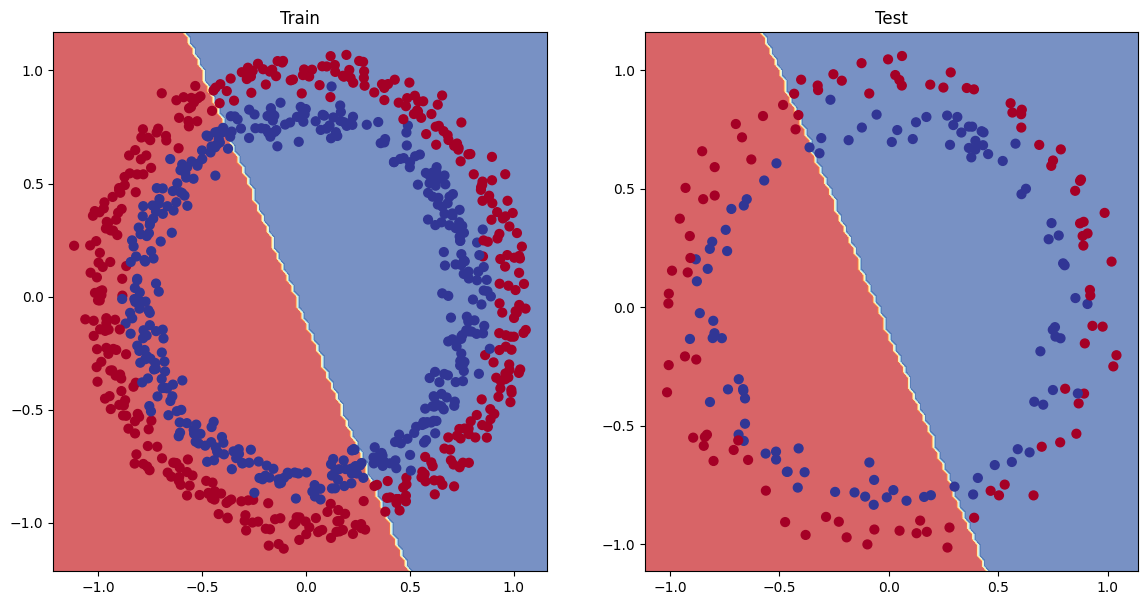

In [169]:
plt.figure(figsize=(14,7))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


## 4. Improving a model (from a model prespoctive)
* Add model layers
* Add more hidden units
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function 

### 4.1 Improve model:
* Adding hidden units: 10 --> 20
* Increase the number of layer: 2 --> 3
* Increate number of epochs: 100 --> 300

In [165]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=1)
    
    def forward(self, x:torch.Tensor):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z

        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1()
model_1        

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=20, bias=True)
  (layer_2): Linear(in_features=20, out_features=20, bias=True)
  (layer_3): Linear(in_features=20, out_features=1, bias=True)
)

In [166]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer 
optimizer = torch.optim.SGD(model_1.parameters(),
                            lr=0.1)

In [31]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 300

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Trainings
    model_1.train()

    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 30 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

        

Epoch: 0 | Loss: 0.70230, Acc:50.00% | Test loss: 0.70127 | Test acc: 50.00%
Epoch: 30 | Loss: 0.69336, Acc:46.62% | Test loss: 0.69352 | Test acc: 45.50%
Epoch: 60 | Loss: 0.69307, Acc:49.62% | Test loss: 0.69381 | Test acc: 49.00%
Epoch: 90 | Loss: 0.69301, Acc:51.12% | Test loss: 0.69414 | Test acc: 47.50%
Epoch: 120 | Loss: 0.69299, Acc:51.00% | Test loss: 0.69434 | Test acc: 46.00%
Epoch: 150 | Loss: 0.69298, Acc:51.12% | Test loss: 0.69447 | Test acc: 46.00%
Epoch: 180 | Loss: 0.69298, Acc:51.12% | Test loss: 0.69455 | Test acc: 46.00%
Epoch: 210 | Loss: 0.69298, Acc:51.25% | Test loss: 0.69459 | Test acc: 46.00%
Epoch: 240 | Loss: 0.69298, Acc:51.50% | Test loss: 0.69462 | Test acc: 45.50%
Epoch: 270 | Loss: 0.69298, Acc:51.50% | Test loss: 0.69464 | Test acc: 45.50%


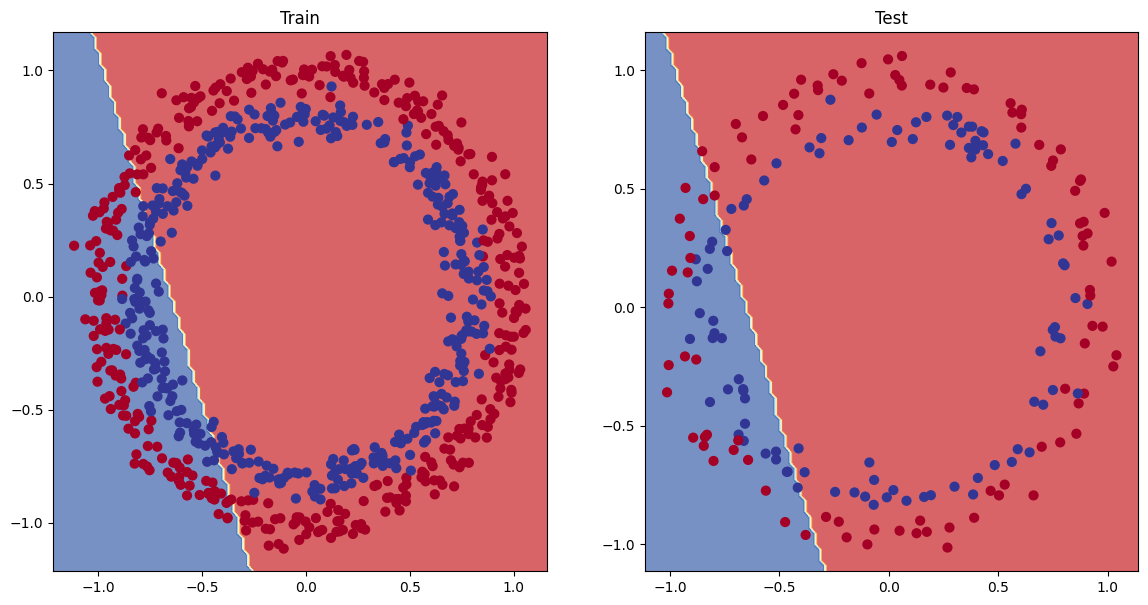

In [172]:
# Plot model decision boundary
plt.figure(figsize=(14,7))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)


### 4.2 Improve model with non-linearity
* Linear = straight line
* Non-linear = non-straight line

ANN are large combination of linear and non-linear function wich are potentially able to find patterns in data 

In [173]:
# Build a model with non-linear activation function


class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=1)

        self.relu = nn.ReLU()

    def forward(self, x:torch.Tensor):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = CircleModelV2()
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=20, bias=True)
  (layer_2): Linear(in_features=20, out_features=20, bias=True)
  (layer_3): Linear(in_features=20, out_features=1, bias=True)
  (relu): ReLU()
)

In [174]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(),
                                lr=0.1)

In [175]:
# Set random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    ### Training
    model_2.train()

    y_logits = model_2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                        y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
        test_logits = model_2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69940, Acc:50.00% | Test loss: 0.70078 | Test acc: 50.00%
Epoch: 100 | Loss: 0.68986, Acc:51.88% | Test loss: 0.69181 | Test acc: 48.00%
Epoch: 200 | Loss: 0.68572, Acc:56.50% | Test loss: 0.68841 | Test acc: 52.00%
Epoch: 300 | Loss: 0.67925, Acc:68.00% | Test loss: 0.68345 | Test acc: 59.00%
Epoch: 400 | Loss: 0.66858, Acc:74.88% | Test loss: 0.67512 | Test acc: 65.50%
Epoch: 500 | Loss: 0.64998, Acc:80.12% | Test loss: 0.66062 | Test acc: 70.50%
Epoch: 600 | Loss: 0.61559, Acc:87.38% | Test loss: 0.63354 | Test acc: 78.00%
Epoch: 700 | Loss: 0.55156, Acc:93.38% | Test loss: 0.58053 | Test acc: 87.00%
Epoch: 800 | Loss: 0.44540, Acc:95.75% | Test loss: 0.49166 | Test acc: 90.00%
Epoch: 900 | Loss: 0.31552, Acc:97.12% | Test loss: 0.37823 | Test acc: 94.00%


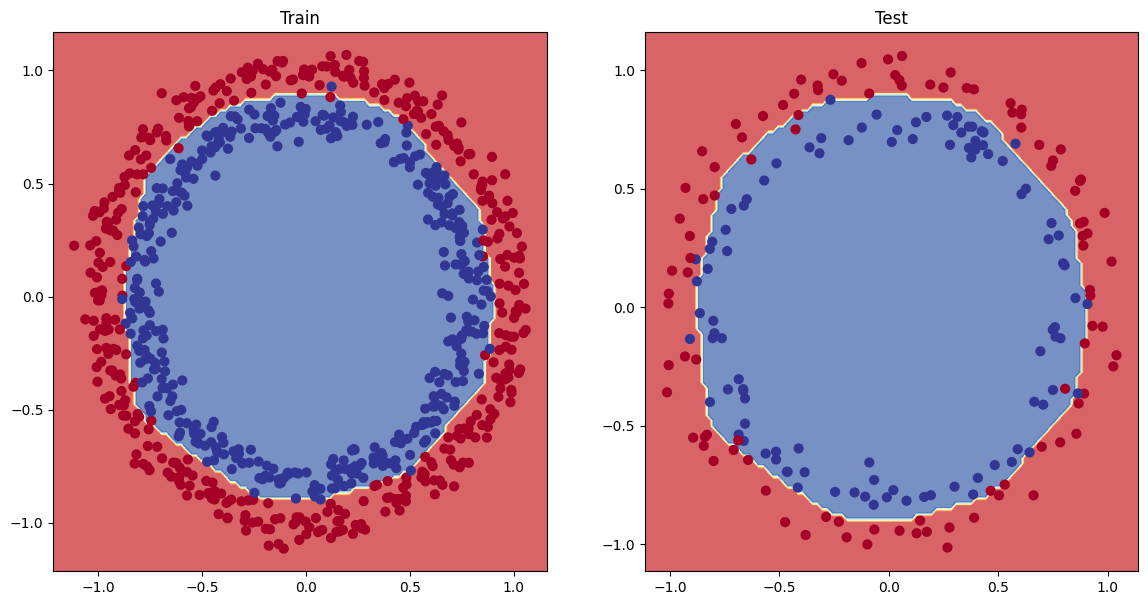

In [177]:
# Plot model decision boundary 
plt.figure(figsize=(14,7))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)


## 5. Replicating non-linear activation functions

In [178]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

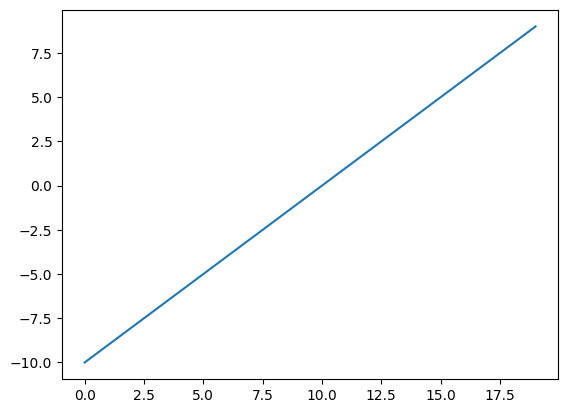

In [179]:
# Visualize the tensor
plt.plot(A);

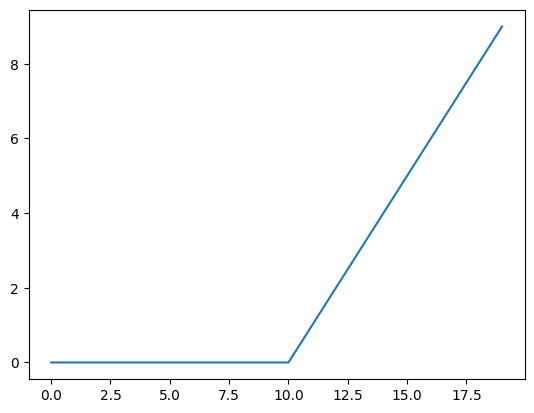

In [180]:
plt.plot(torch.relu(A));

In [181]:
def relu(x):
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

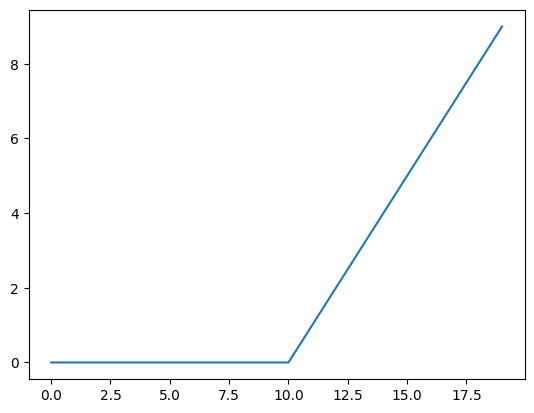

In [182]:
plt.plot(relu(A));

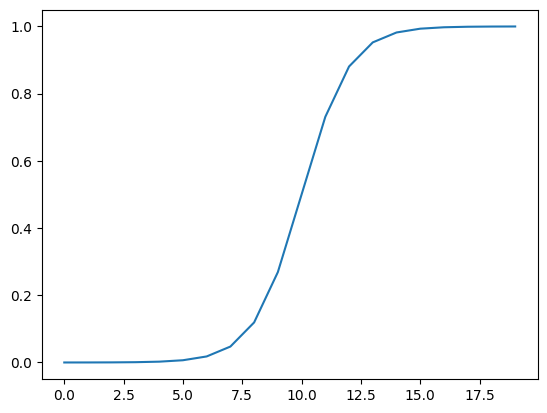

In [183]:
plt.plot(torch.sigmoid(A));

In [184]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

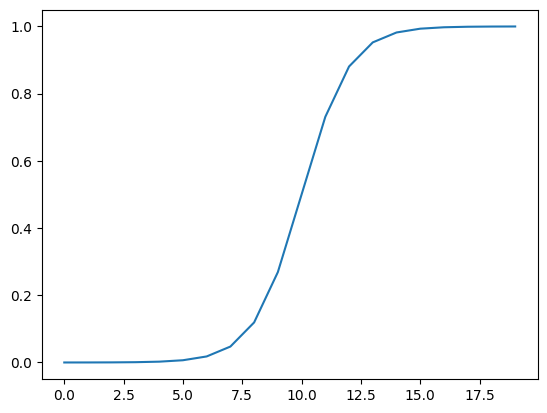

In [185]:
plt.plot(sigmoid(A));

## 6. Putting it all together with a multi-class classification problem

### 6.1 Data

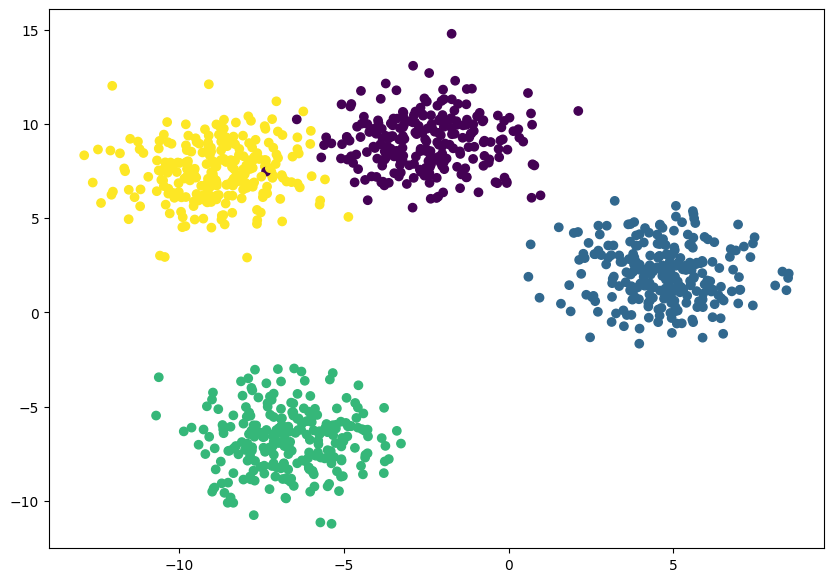

In [186]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameter for data creation
NUM_CLASSES = 4
NUM_FEATURE = 2
RANDOM_SEED = 42

# Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURE,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)
# Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# Split into train/test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob);

### 6.2 Model

In [187]:
# Create device agonstic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [188]:
# Build a multi-class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """
            Initializes multi-class classfication model.

            Args:
                input_features (int): Number of input features to the model
                output_features (int): Number of outputs features (number of otuput classes)
                hidden_units (int): Number of hidden units between layers, default 8
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

model_3 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
model_3

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 6.3 Loss function & optimizer

In [189]:
# Loss function for multi-class classfication
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.SGD(model_3.parameters(),
                                lr=0.1)

### 6.4 Getting prediction probabilites a multi-class

In [190]:
len(X_blob_train), len(X_blob_test), len(y_blob_train), len(y_blob_test)

(800, 200, 800, 200)

In [191]:
model_3.eval()
with torch.inference_mode():
    y_logits = model_3(X_blob_test.to(device))
y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [192]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [193]:
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [194]:
torch.sum(y_pred_probs[0])

tensor(1.)

In [195]:
torch.max(y_pred_probs[0])

tensor(0.3244)

In [196]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

In [197]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

### 6.5 Creating a trainng/testing loop

In [198]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

# Put data to the target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training 
    model_3.train()

    y_logits = model_3(X_blob_train)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_blob_train, y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_blob_test, test_preds)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc:{acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")
    


Epoch: 0 | Loss: 1.15883, Acc:40.38% | Test loss: 1.07554 | Test acc: 48.00%
Epoch: 10 | Loss: 0.64476, Acc:96.75% | Test loss: 0.66069 | Test acc: 97.50%
Epoch: 20 | Loss: 0.42535, Acc:98.50% | Test loss: 0.43074 | Test acc: 100.00%
Epoch: 30 | Loss: 0.25294, Acc:99.12% | Test loss: 0.24508 | Test acc: 99.50%
Epoch: 40 | Loss: 0.11232, Acc:99.25% | Test loss: 0.10229 | Test acc: 99.50%
Epoch: 50 | Loss: 0.06627, Acc:99.25% | Test loss: 0.05848 | Test acc: 99.50%
Epoch: 60 | Loss: 0.05068, Acc:99.25% | Test loss: 0.04293 | Test acc: 99.50%
Epoch: 70 | Loss: 0.04300, Acc:99.25% | Test loss: 0.03491 | Test acc: 99.50%
Epoch: 80 | Loss: 0.03836, Acc:99.25% | Test loss: 0.02988 | Test acc: 99.50%
Epoch: 90 | Loss: 0.03525, Acc:99.25% | Test loss: 0.02663 | Test acc: 99.50%


### 6.6 Making and evaluating prediction with multi-class model

In [199]:
model_3.eval()
with torch.inference_mode():
    y_logits = model_3(X_blob_test)

y_logits[:10]

tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9466],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3761, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]])

In [200]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[1.3438e-03, 9.9865e-01, 1.2164e-06, 5.3854e-07],
        [4.9905e-03, 7.4740e-05, 1.0630e-03, 9.9387e-01],
        [1.3985e-03, 8.6060e-04, 9.9463e-01, 3.1073e-03],
        [4.7389e-03, 9.9483e-01, 3.1956e-04, 1.1353e-04],
        [9.9388e-01, 6.0966e-03, 2.4904e-06, 2.2378e-05],
        [1.3372e-03, 1.1504e-05, 3.0644e-04, 9.9834e-01],
        [2.9138e-03, 2.1537e-03, 9.8781e-01, 7.1181e-03],
        [9.9838e-01, 6.0198e-04, 3.4435e-05, 9.7989e-04],
        [2.8147e-04, 1.5016e-04, 9.9882e-01, 7.5044e-04],
        [9.9825e-01, 1.4575e-03, 1.5998e-05, 2.7210e-04]])

In [201]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [202]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

### 6.7 Plot model decision boundary

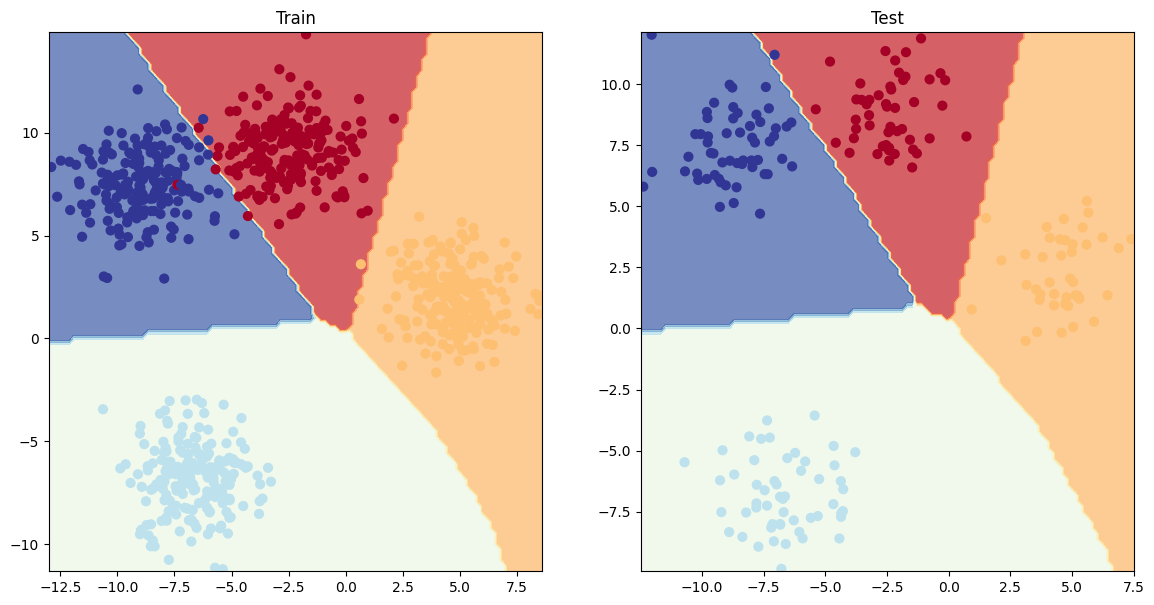

In [204]:
plt.figure(figsize=(14,7))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_blob_test, y_blob_test)
